# Chapter 5: Linear Models and Regularization

## 📋 Summary

Linear models are among the most fundamental and widely used tools in machine learning. Despite their simplicity, they are highly interpretable, computationally efficient, and often competitive with more complex models. This chapter covers linear regression, Ridge, Lasso, and ElasticNet regression — all variants that add **regularization** to control model complexity.

Regularization prevents **overfitting** by penalizing large coefficients. The chapter explains when to use each regularization method, how to select the regularization strength (alpha), and how to implement these models with scikit-learn.

---

## 🧠 Theoretical Explanation

### Linear Regression
Linear regression finds coefficients β that minimize the **Mean Squared Error (MSE)**:

`Loss = Σ(yi - ŷi)² = Σ(yi - Xβ)²`

The closed-form solution is `β = (X^T X)^(-1) X^T y`.

### Ridge Regression (L2 Regularization)
Adds a penalty proportional to the **square** of coefficients:

`Loss = Σ(yi - Xβ)² + α·Σβj²`

- Shrinks all coefficients toward zero, but never to exactly zero
- Best when all features are relevant
- α controls regularization strength (larger α = more shrinkage)

### Lasso Regression (L1 Regularization)
Adds a penalty proportional to the **absolute value** of coefficients:

`Loss = Σ(yi - Xβ)² + α·Σ|βj|`

- Can shrink coefficients to **exactly zero** → automatic feature selection
- Best when you suspect many features are irrelevant (sparse solutions)

### ElasticNet
Combines L1 and L2 penalties:

`Loss = Σ(yi - Xβ)² + α·(l1_ratio·Σ|βj| + (1-l1_ratio)·Σβj²)`

- More flexible than pure Ridge or Lasso
- `l1_ratio=1` → Lasso; `l1_ratio=0` → Ridge
- Best when there are groups of correlated features

### Bias-Variance Tradeoff
Regularization increases bias but reduces variance — the key is finding the right balance via cross-validation over α.


## 5.1 Linear Regression

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Generate regression dataset (no download needed)
X, y = make_regression(n_samples=5000, n_features=8, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
lr_pipe.fit(X_train, y_train)
y_pred = lr_pipe.predict(X_test)

print(f'Linear Regression:')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')
print(f'  Coefficients: {lr_pipe.named_steps["lr"].coef_.round(2)}')


Linear Regression:
  RMSE: 9.9678
  R²:   0.9959
  Coefficients: [ 5.03 83.71 92.12 71.59  5.21 46.67 27.44 33.97]


## 5.2 Ridge Regression (L2)

In [2]:
from sklearn.linear_model import Ridge, RidgeCV

# RidgeCV automatically selects best alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])
ridge_cv.fit(X_train, y_train)
y_pred = ridge_cv.predict(X_test)

print(f'Ridge (RidgeCV):')
print(f'  Best alpha: {ridge_cv.named_steps["ridge"].alpha_}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')

Ridge (RidgeCV):
  Best alpha: 0.01
  RMSE: 9.9678
  R²:   0.9959


## 5.3 Lasso Regression (L1)

Lasso (LassoCV):
  Best alpha: 0.0933
  RMSE: 9.9610
  R²:   0.9959
  Coefficients set to zero: 0/8


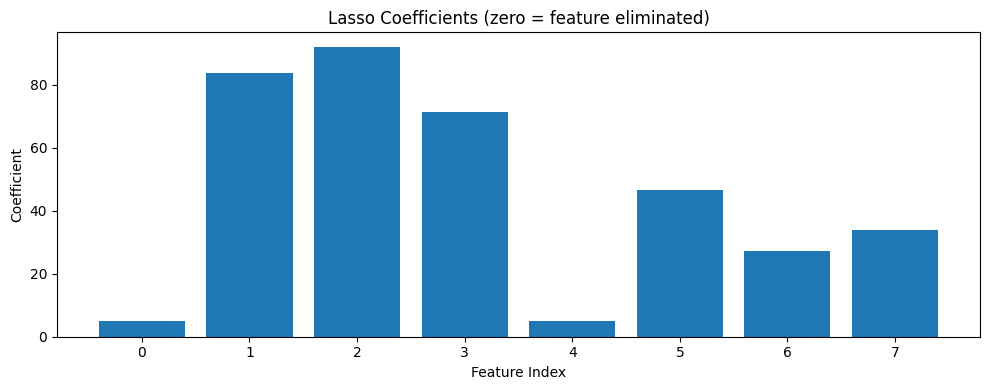

In [3]:
from sklearn.linear_model import Lasso, LassoCV
import matplotlib.pyplot as plt

lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=5000))
])
lasso_cv.fit(X_train, y_train)
y_pred = lasso_cv.predict(X_test)

coefs = lasso_cv.named_steps['lasso'].coef_
n_zero = np.sum(coefs == 0)

print(f'Lasso (LassoCV):')
print(f'  Best alpha: {lasso_cv.named_steps["lasso"].alpha_:.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')
print(f'  Coefficients set to zero: {n_zero}/{len(coefs)}')

# Visualize coefficients
plt.figure(figsize=(10, 4))
plt.bar(range(len(coefs)), coefs)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient')
plt.title('Lasso Coefficients (zero = feature eliminated)')
plt.tight_layout()
plt.show()

## 5.4 ElasticNet Regression

In [4]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

enet_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('enet', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], cv=5, max_iter=5000, random_state=42))
])
enet_cv.fit(X_train, y_train)
y_pred = enet_cv.predict(X_test)

print(f'ElasticNet:')
print(f'  Best alpha: {enet_cv.named_steps["enet"].alpha_:.4f}')
print(f'  Best l1_ratio: {enet_cv.named_steps["enet"].l1_ratio_}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'  R²:   {r2_score(y_test, y_pred):.4f}')

ElasticNet:
  Best alpha: 0.0933
  Best l1_ratio: 1.0
  RMSE: 9.9610
  R²:   0.9959


## 5.5 Comparing All Regularization Methods

In [5]:
import pandas as pd

results = []
models = [
    ('Linear Regression', Pipeline([('s', StandardScaler()), ('m', LinearRegression())])),
    ('Ridge', Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=1.0))])),
    ('Lasso', Pipeline([('s', StandardScaler()), ('m', Lasso(alpha=0.01, max_iter=5000))])),
    ('ElasticNet', Pipeline([('s', StandardScaler()), ('m', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000))]))
]

for name, model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({'Model': name,
                    'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 4),
                    'R²': round(r2_score(y_test, pred), 4)})

pd.DataFrame(results)

,Model,RMSE,R²
0,Linear Regression,9.9678,0.9959
1,Ridge,9.9655,0.9959
2,Lasso,9.9668,0.9959
3,ElasticNet,9.9513,0.9960


## 🔑 Key Takeaways

- **Linear Regression** minimizes MSE without constraints — can overfit with many features.
- **Ridge (L2)** shrinks coefficients toward zero — best when all features contribute.
- **Lasso (L1)** drives some coefficients to exactly zero — built-in feature selection.
- **ElasticNet** combines L1 and L2 — best for correlated features or when you want some sparsity.
- Always use `RidgeCV`, `LassoCV`, or `ElasticNetCV` to automatically select the best `alpha`.
- **Always scale features** before regularized models — the penalty is scale-sensitive.
